In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = "giripande"
os.environ['KAGGLE_KEY'] = "a39cef068914b1050587a4e430b45820"

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d rmisra/news-category-dataset

Dataset URL: https://www.kaggle.com/datasets/rmisra/news-category-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 26.5M/26.5M [00:00<00:00, 128MB/s] 



In [ ]:
!unzip news-category-dataset.zip

Archive:  news-category-dataset.zip
  inflating: News_Category_Dataset_v3.json  


In [ ]:
import pandas as pd

df = pd.read_json("News_Category_Dataset_v3.json", lines=True)
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


Dataset Shape: (209527, 6)

Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']

Total Categories: 42


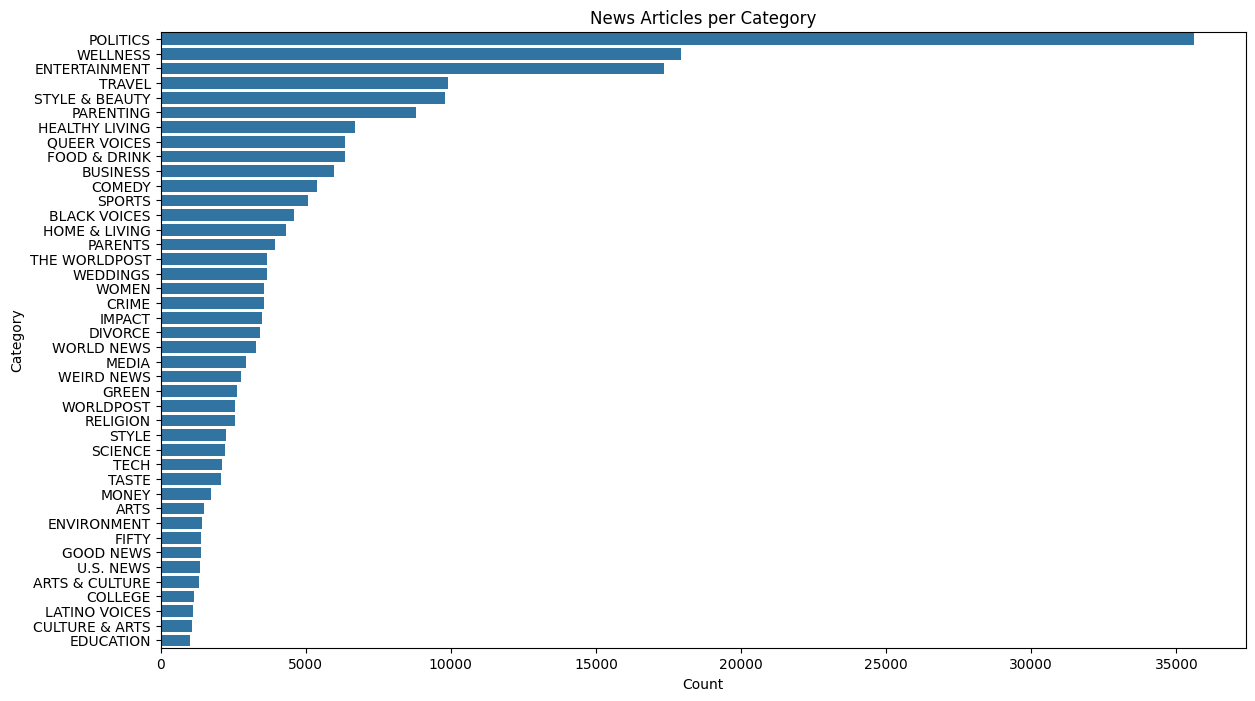

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTotal Categories:", df["category"].nunique())


# 1. Category Distribution

plt.figure(figsize=(14, 8))
sns.countplot(y=df["category"], order=df["category"].value_counts().index)
plt.title("News Articles per Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

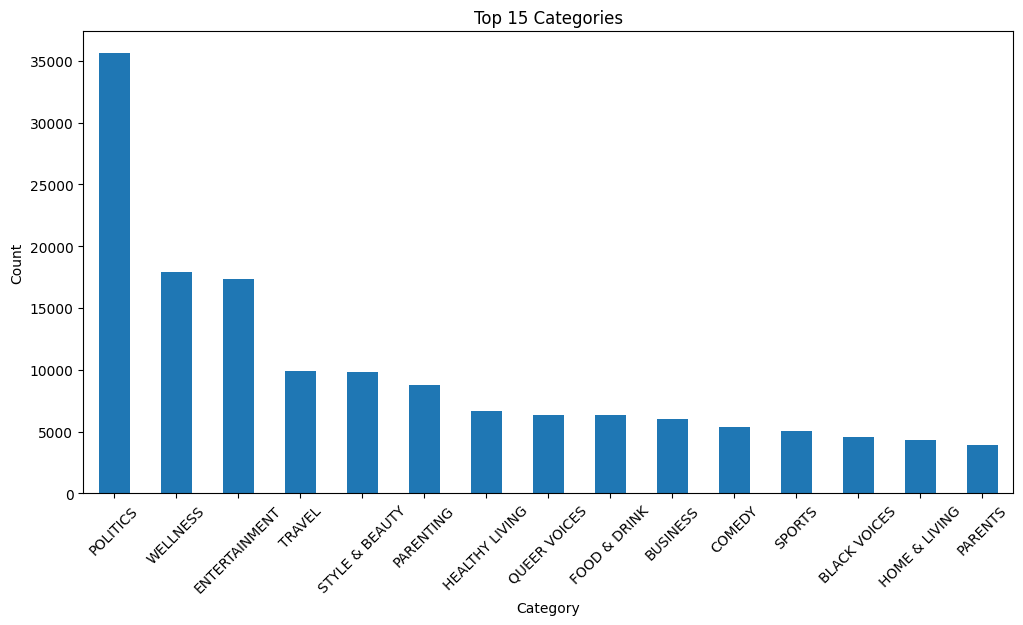

In [ ]:

# 2. Top 15 Categories

top15 = df["category"].value_counts().head(15)

plt.figure(figsize=(12, 6))
top15.plot(kind="bar")
plt.title("Top 15 Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

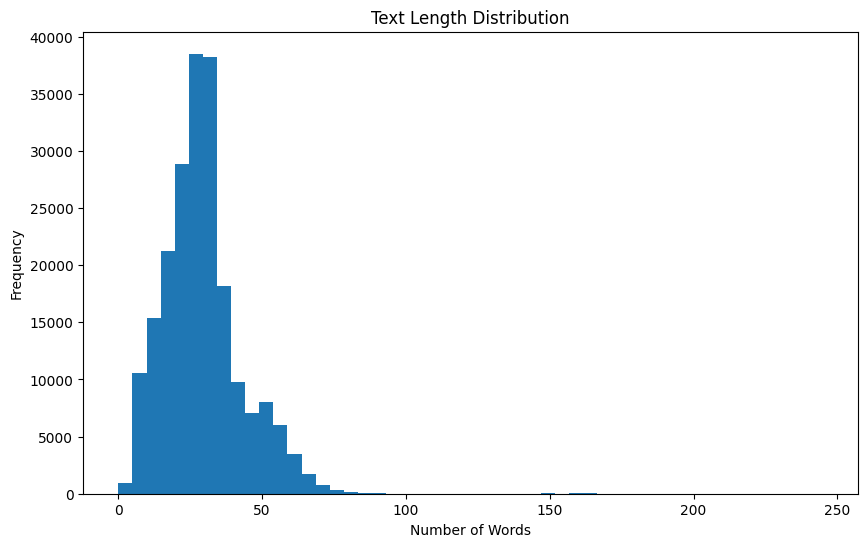

In [ ]:

# 3. Text Length Analysis

df["headline"] = df["headline"].fillna("")
df["short_description"] = df["short_description"].fillna("")

df["temp_text"] = df["headline"] + " " + df["short_description"]
df["text_length"] = df["temp_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
plt.hist(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

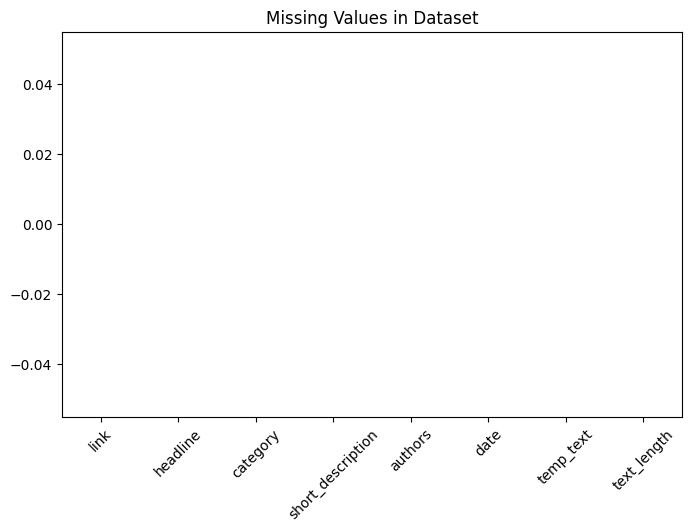


Missing Values:
 link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
temp_text            0
text_length          0
dtype: int64


In [ ]:

# 5. Missing Values

missing = df.isnull().sum()

plt.figure(figsize=(8, 5))
missing.plot(kind="bar")
plt.title("Missing Values in Dataset")
plt.xticks(rotation=45)
plt.show()

print("\nMissing Values:\n", missing)

In [ ]:
# Cell 7 — keep almost all categories, remove very rare ones only

min_samples = 200

category_counts = df["category"].value_counts()
valid_categories = category_counts[category_counts >= min_samples].index

df = df[df["category"].isin(valid_categories)].copy()

print("Remaining categories:", df["category"].nunique())
print("New dataset shape:", df.shape)
print("\nCategory counts:\n")
print(df["category"].value_counts())

Remaining categories: 42
New dataset shape: (209527, 8)

Category counts:

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLL

In [ ]:
df["headline"] = df["headline"].fillna("")
df["short_description"] = df["short_description"].fillna("")

df["text"] = (df["headline"] + " " + df["short_description"]).str.strip()

df = df[df["text"] != ""].copy()

df[["category", "text"]].head()

,category,text
0,U.S. NEWS,Over 4 Million Americans Roll Up Sleeves For O...
1,U.S. NEWS,"American Airlines Flyer Charged, Banned For Li..."
2,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...
3,PARENTING,The Funniest Tweets From Parents This Week (Se...
4,U.S. NEWS,Woman Who Called Cops On Black Bird-Watcher Lo...


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["category"])

print("Total labels:", len(label_encoder.classes_))
print("\nLabel mapping:\n")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "->", class_name)

Total labels: 42

Label mapping:

0 -> ARTS
1 -> ARTS & CULTURE
2 -> BLACK VOICES
3 -> BUSINESS
4 -> COLLEGE
5 -> COMEDY
6 -> CRIME
7 -> CULTURE & ARTS
8 -> DIVORCE
9 -> EDUCATION
10 -> ENTERTAINMENT
11 -> ENVIRONMENT
12 -> FIFTY
13 -> FOOD & DRINK
14 -> GOOD NEWS
15 -> GREEN
16 -> HEALTHY LIVING
17 -> HOME & LIVING
18 -> IMPACT
19 -> LATINO VOICES
20 -> MEDIA
21 -> MONEY
22 -> PARENTING
23 -> PARENTS
24 -> POLITICS
25 -> QUEER VOICES
26 -> RELIGION
27 -> SCIENCE
28 -> SPORTS
29 -> STYLE
30 -> STYLE & BEAUTY
31 -> TASTE
32 -> TECH
33 -> THE WORLDPOST
34 -> TRAVEL
35 -> U.S. NEWS
36 -> WEDDINGS
37 -> WEIRD NEWS
38 -> WELLNESS
39 -> WOMEN
40 -> WORLD NEWS
41 -> WORLDPOST


In [ ]:
!pip -q install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train size:", len(train_texts))
print("Test size :", len(test_texts))

Train size: 167617
Test size : 41905


In [ ]:
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_dict({
    "text": train_texts,
    "label": train_labels
})

test_dataset = Dataset.from_dict({
    "text": test_texts,
    "label": test_labels
})

dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 167617
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 41905
    })
})

In [ ]:
from transformers import AutoTokenizer

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/167617 [00:00<?, ? examples/s]

Map:   0%|          | 0/41905 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

num_labels = len(label_encoder.classes_)

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./news_classifier",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": acc,
        "weighted_f1": f1
    }

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1
1,1.317353,1.041211,0.694332,0.683371
2,0.882329,1.011539,0.703281,0.696352
3,0.663553,1.033888,0.713256,0.706115
4,0.500028,1.109698,0.705453,0.701486
5,0.390221,1.170990,0.704379,0.701388


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=52385, training_loss=0.7506968575510642, metrics={'train_runtime': 10048.9889, 'train_samples_per_second': 83.4, 'train_steps_per_second': 5.213, 'total_flos': 2.777453360250624e+16, 'train_loss': 0.7506968575510642, 'epoch': 5.0})

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 1.0338797569274902, 'eval_accuracy': 0.7133277651831523, 'eval_weighted_f1': 0.7061855989408744, 'eval_runtime': 151.4254, 'eval_samples_per_second': 276.737, 'eval_steps_per_second': 17.302, 'epoch': 5.0}


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

pred_output = trainer.predict(tokenized_dataset["test"])
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = pred_output.label_ids

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

                precision    recall  f1-score   support

          ARTS       0.57      0.52      0.55       302
ARTS & CULTURE       0.56      0.48      0.52       268
  BLACK VOICES       0.63      0.50      0.56       917
      BUSINESS       0.60      0.60      0.60      1198
       COLLEGE       0.51      0.61      0.56       229
        COMEDY       0.61      0.57      0.59      1080
         CRIME       0.67      0.64      0.66       712
CULTURE & ARTS       0.58      0.50      0.54       215
       DIVORCE       0.84      0.82      0.83       685
     EDUCATION       0.51      0.49      0.50       203
 ENTERTAINMENT       0.75      0.81      0.78      3473
   ENVIRONMENT       0.66      0.51      0.58       289
         FIFTY       0.61      0.38      0.47       280
  FOOD & DRINK       0.75      0.82      0.78      1268
     GOOD NEWS       0.49      0.36      0.42       280
         GREEN       0.51      0.55      0.53       524
HEALTHY LIVING       0.64      0.41      0.50  

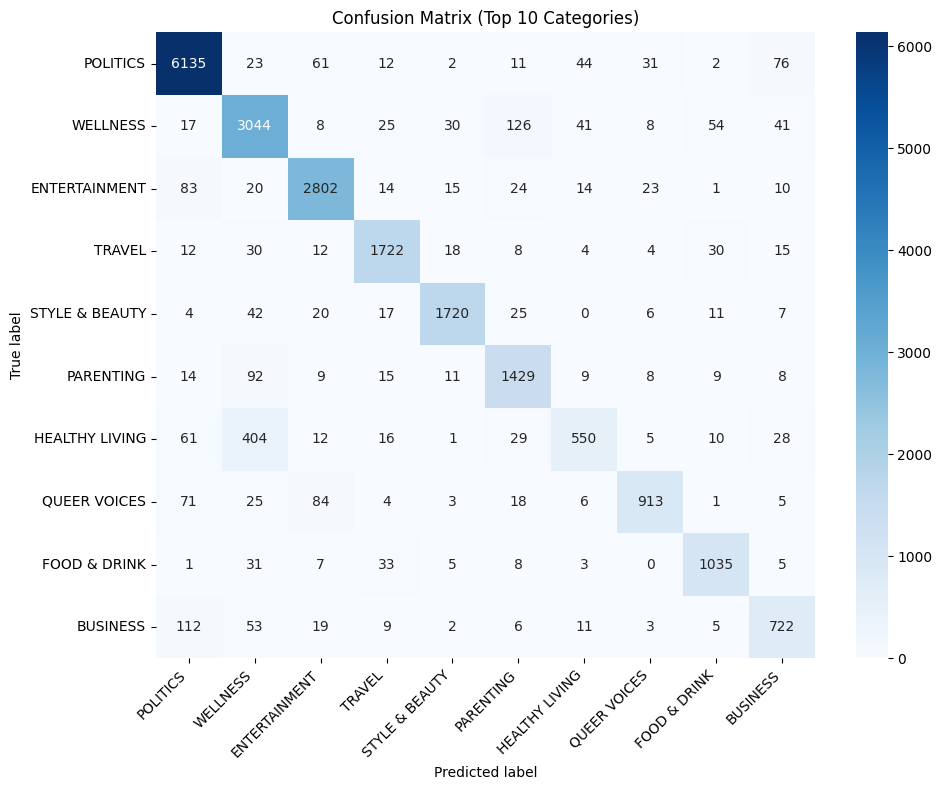

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# y_true and y_pred were already computed in the previous cell and are available.

# top 10 classes by support in test data
top10 = pd.Series(y_true).value_counts().head(10).index

# keep only samples belonging to top 10 classes
mask = np.isin(y_true, top10)
y_true_top = y_true[mask]
y_pred_top = y_pred[mask]

# confusion matrix for top 10 classes
cm_top = confusion_matrix(y_true_top, y_pred_top, labels=top10)

# class names
labels_top = label_encoder.inverse_transform(top10)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_top, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_top, yticklabels=labels_top)
plt.title("Confusion Matrix (Top 10 Categories)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import torch

def predict_news(text):
    inputs = tokenizer(text, truncation=True, padding="max_length", max_length=128, return_tensors="pt")
    # Move input tensors to the same device as the model
    inputs = {key: value.to(model.device) for key, value in inputs.items()}
    outputs = model(**inputs)
    logits = outputs.logits
    prediction = logits.argmax().item()
    return label_encoder.inverse_transform([prediction])[0]

text1 = "The government announced new policies to improve the economy and healthcare system."
print(predict_news(text1))

text2 = "India won the cricket match after a thrilling final over performance."
print(predict_news(text2))

text3 = "Stock markets saw a significant rise as major companies reported strong quarterly earnings."
print(predict_news(text3))

text4 = "The restaurant introduced a new menu featuring delicious international cuisines."
print(predict_news(text4))

text5 = "New advancements in artificial intelligence are transforming the tech industry."
print(predict_news(text5))

POLITICS
SPORTS
BUSINESS
TASTE
TECH


In [ ]:
model.save_pretrained("saved_news_classifier")
tokenizer.save_pretrained("saved_news_classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('saved_news_classifier/tokenizer_config.json',
 'saved_news_classifier/tokenizer.json')

In [ ]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [ ]:
!zip -r saved_news_classifier.zip saved_news_classifier label_encoder.pkl

  adding: saved_news_classifier/ (stored 0%)
  adding: saved_news_classifier/config.json (deflated 69%)
  adding: saved_news_classifier/model.safetensors (deflated 8%)
  adding: saved_news_classifier/tokenizer.json (deflated 71%)
  adding: saved_news_classifier/tokenizer_config.json (deflated 42%)
  adding: label_encoder.pkl (deflated 30%)


In [ ]:
from google.colab import files
files.download("saved_news_classifier.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
'''

'''